In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df = pd.read_csv('./mtcars.csv')

In [2]:
df.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [3]:
df.tail()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
28,Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
29,Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
30,Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8
31,Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.6,1,1,4,2


In [4]:
print("데이터 모양(행, 열):", df.shape)

row_count = df.shape[0]
print(f"데이터의 개수(row count): {row_count}")

데이터 모양(행, 열): (32, 12)
데이터의 개수(row count): 32


In [5]:
print("변경 전:", df.columns)
df.rename(columns={'Unnamed: 0': 'car_name'}, inplace=True)
print("변경 후:", df.columns)

변경 전: Index(['Unnamed: 0', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs',
       'am', 'gear', 'carb'],
      dtype='str')
변경 후: Index(['car_name', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs',
       'am', 'gear', 'carb'],
      dtype='str')


In [6]:
print(df.dtypes)
print("-----------------------------------")
df.info()
print("-----------------------------------")
print(df.describe())

car_name        str
mpg         float64
cyl           int64
disp        float64
hp            int64
drat        float64
wt          float64
qsec        float64
vs            int64
am            int64
gear          int64
carb          int64
dtype: object
-----------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   car_name  32 non-null     str    
 1   mpg       32 non-null     float64
 2   cyl       32 non-null     int64  
 3   disp      32 non-null     float64
 4   hp        32 non-null     int64  
 5   drat      32 non-null     float64
 6   wt        32 non-null     float64
 7   qsec      32 non-null     float64
 8   vs        32 non-null     int64  
 9   am        32 non-null     int64  
 10  gear      32 non-null     int64  
 11  carb      32 non-null     int64  
dtypes: float64(5), int64(6), str(1)
memory usage: 3.1 KB
--------------

In [7]:
gear_unique_counts = df['gear'].nunique()
transmission_unique_counts = df['am'].nunique()
print(f"gear 컬럼의 고유값 개수: {gear_unique_counts}")
print(f"transmission 컬럼의 고유값 개수: {transmission_unique_counts}")


gear 컬럼의 고유값 개수: 3
transmission 컬럼의 고유값 개수: 2


In [8]:
ct_result = pd.crosstab(df['gear'], df['am'])
ct_result = ct_result.stack().reset_index(name='# of cars')
ct_result.columns = ['gear', 'am', '# of cars']

print("# of Cars by Gear x Transmission (using crosstab):")
print(ct_result)

# of Cars by Gear x Transmission (using crosstab):
   gear  am  # of cars
0     3   0         15
1     3   1          0
2     4   0          4
3     4   1          8
4     5   0          0
5     5   1          5


In [9]:
combo_counts = df.groupby(['gear', 'am']).size().reset_index(name='count')
combo_counts.columns = ['gear', 'am', '# of cars']
print("# of Cars by Gear x Transmission:")
print(combo_counts)

# of Cars by Gear x Transmission:
   gear  am  # of cars
0     3   0         15
1     4   0          4
2     4   1          8
3     5   1          5


<Figure size 1000x600 with 0 Axes>

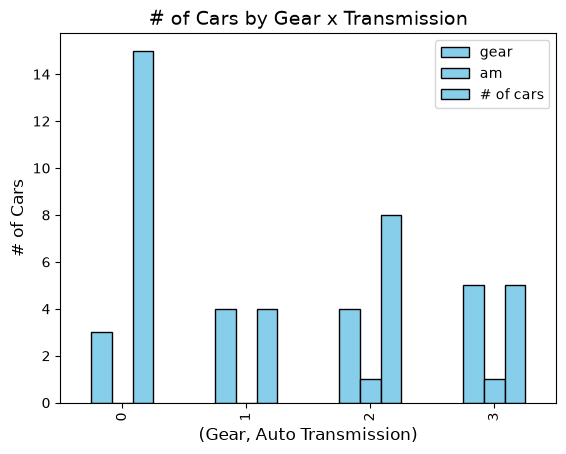

In [10]:
plt.figure(figsize =(10, 6))
combo_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("# of Cars by Gear x Transmission", fontsize=14)
plt.xlabel("(Gear, Auto Transmission)", fontsize=12)
plt.ylabel("# of Cars", fontsize=12)
plt.show()

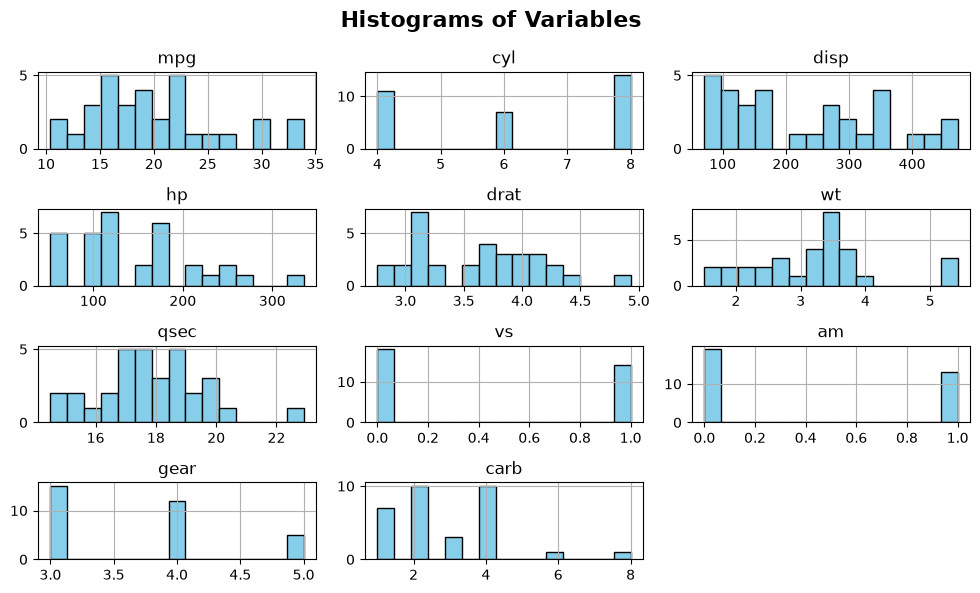

In [11]:
df.hist(figsize=(10, 6), bins=15, color='skyblue', edgecolor='black')
plt.suptitle("Histograms of Variables", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


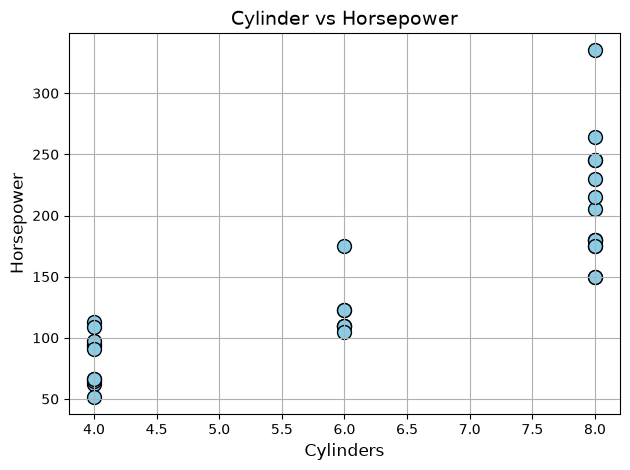

In [12]:
plt.scatter(df['cyl'], df['hp'], s=100, color='skyblue', edgecolor='black')
plt.title("Cylinder vs Horsepower", fontsize=14)
plt.xlabel("Cylinders", fontsize=12)
plt.ylabel("Horsepower", fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

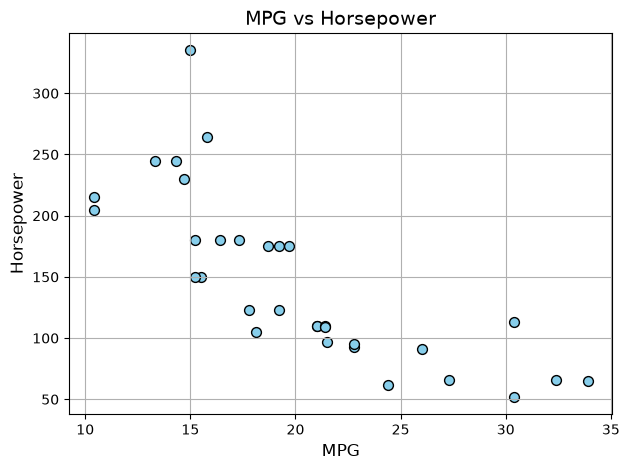

In [13]:
plt.scatter(df['mpg'], df['hp'], s=50, color='skyblue', edgecolor='black')
plt.title("MPG vs Horsepower", fontsize=14)
plt.xlabel("MPG", fontsize=12)
plt.ylabel("Horsepower", fontsize=12)
plt.grid(True) 

plt.tight_layout()
plt.show()

In [14]:
corr_matrix = df.corr(numeric_only=True)
print("상관계수 표:")
print(corr_matrix)

상관계수 표:
           mpg       cyl      disp        hp      drat        wt      qsec  \
mpg   1.000000 -0.852162 -0.847551 -0.776168  0.681172 -0.867659  0.418684   
cyl  -0.852162  1.000000  0.902033  0.832447 -0.699938  0.782496 -0.591242   
disp -0.847551  0.902033  1.000000  0.790949 -0.710214  0.887980 -0.433698   
hp   -0.776168  0.832447  0.790949  1.000000 -0.448759  0.658748 -0.708223   
drat  0.681172 -0.699938 -0.710214 -0.448759  1.000000 -0.712441  0.091205   
wt   -0.867659  0.782496  0.887980  0.658748 -0.712441  1.000000 -0.174716   
qsec  0.418684 -0.591242 -0.433698 -0.708223  0.091205 -0.174716  1.000000   
vs    0.664039 -0.810812 -0.710416 -0.723097  0.440278 -0.554916  0.744535   
am    0.599832 -0.522607 -0.591227 -0.243204  0.712711 -0.692495 -0.229861   
gear  0.480285 -0.492687 -0.555569 -0.125704  0.699610 -0.583287 -0.212682   
carb -0.550925  0.526988  0.394977  0.749812 -0.090790  0.427606 -0.656249   

            vs        am      gear      carb  
mpg   0.